# 03 — Eksperimenti sa treniranjem modela

Cilj je da pronađemo najbolje vrednosti za **batch size, learning rate i temperature** za projekcione slojeve multimodalnog modela.

**Strogo razdvajamo tri skupa:**
- `train.pt` — koristi se isključivo za treniranje
- `validation.pt` — koristi se za izbor hiperparametara i finalnog modela
- `test.pt` — **ne dodiruje se uopšte u ovom notebook-u** i ostaje rezervisan za konačnu evaluaciju izabranog modela.

Prvo radimo kratak screening svih kombinacija, a zatim najbolje konfiguracije treniramo 30 epoha.


In [5]:
from pathlib import Path
import itertools
import json
import random

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from vision_language_clothing_retrieval.retrieval.embedding_dataset import EmbeddingDataset
from vision_language_clothing_retrieval.retrieval.model import MultimodalModel
from vision_language_clothing_retrieval.retrieval.trainer import MultimodalTrainer

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

TRAIN_PATH = ROOT / "embeddings/train.pt"
VAL_PATH = ROOT / "embeddings/validation.pt"
RESULTS_DIR = ROOT / "embeddings/experiments"
RESULTS_DIR.mkdir(exist_ok=True)

DEVICE = "cpu"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train_data = torch.load(TRAIN_PATH, weights_only=True)
val_data = torch.load(VAL_PATH, weights_only=True)

train_dataset = EmbeddingDataset(train_data)
val_dataset = EmbeddingDataset(val_data)

print("Broj uzoraka za treniranje:", len(train_dataset))
print("Broj uzoraka za validaciju:", len(val_dataset))


Broj uzoraka za treniranje: 34047
Broj uzoraka za validaciju: 4354


## 1. Grid Search

Definišemo samo skup mogućih vrednosti — `GridSearch` sam pravi sve kombinacije (Dekartov proizvod) i trenira/evaluira svaku.

Koristimo:

- batch size: `16, 32` — manje vrednosti su namerno izabrane jer je dataset za treniranje projekcionih slojeva umeren po veličini, a manji batch daje više koraka optimizacije po epohi,
- learning rate: `0.001, 0.003, 0.005` — raspon oko uobičajene Adam podrazumevane vrednosti,
- temperature: `0.07, 0.1, 0.15` — 0.07 je standardna vrednost iz literature, testiramo i okolne vrednosti da vidimo da li nešto blago drugačije bolje odgovara ovom manjem datasetu.

Ukupno: **18 kombinacija**, svaka sa po 5 epoha (screening faza) — dovoljno da se stekne gruba slika bez trošenja previše vremena na kombinacije koje očigledno ne obećavaju.


In [6]:
class GridSearch:
    def __init__(self, param_grid, epochs=5):
        self.param_grid = param_grid
        self.epochs = epochs
        self.results = []

    def fit(self):
        keys = list(self.param_grid)
        values = [self.param_grid[k] for k in keys]

        for params in itertools.product(*values):
            config = dict(zip(keys, params))

            torch.manual_seed(SEED)

            train_loader = DataLoader(
                train_dataset,
                batch_size=config["batch_size"],
                shuffle=True,
            )
            val_loader = DataLoader(
                val_dataset,
                batch_size=config["batch_size"],
                shuffle=False,
            )

            model = MultimodalModel()
            trainer = MultimodalTrainer(
                model=model,
                learning_rate=config["learning_rate"],
                temperature=config["temperature"],
            )

            best_val_loss = float("inf")

            for epoch in range(self.epochs):
                trainer.train_epoch(train_loader, DEVICE)
                val_loss = trainer.evaluate_epoch(val_loader, DEVICE)
                best_val_loss = min(best_val_loss, val_loss)

            result = {**config, "best_val_loss": best_val_loss}
            self.results.append(result)

            print("Konfiguracija:", config, "-> najbolji validation loss:", round(best_val_loss, 4))

        return self

    def results_table(self):
        return pd.DataFrame(self.results).sort_values(
            "best_val_loss"
        ).reset_index(drop=True)


In [7]:
param_grid = {
    "batch_size": [16, 32],
    "learning_rate": [0.001, 0.003, 0.005],
    "temperature": [0.07, 0.1, 0.15],
}

grid_search = GridSearch(
    param_grid=param_grid,
    epochs=5,
)

grid_search.fit()


Konfiguracija: {'batch_size': 16, 'learning_rate': 0.001, 'temperature': 0.07} -> najbolji validation loss: 1.8585
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.001, 'temperature': 0.1} -> najbolji validation loss: 1.8721
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.001, 'temperature': 0.15} -> najbolji validation loss: 1.8531
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.003, 'temperature': 0.07} -> najbolji validation loss: 1.8666
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.003, 'temperature': 0.1} -> najbolji validation loss: 1.8718
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.003, 'temperature': 0.15} -> najbolji validation loss: 1.8595
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.005, 'temperature': 0.07} -> najbolji validation loss: 1.8746
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.005, 'temperature': 0.1} -> najbolji validation loss: 1.8743
Konfiguracija: {'batch_size': 16, 'learning_rate': 0.005, 'temperature': 0.15} -> n

In [8]:
screening_results = grid_search.results_table()
screening_results


,batch_size,learning_rate,temperature,best_val_loss
0,16,0.001,0.15,1.853073
1,16,0.005,0.15,1.858343
2,16,0.001,0.07,1.858522
3,16,0.003,0.15,1.859505
4,16,0.003,0.07,1.866607
5,16,0.003,0.10,1.871850
6,16,0.001,0.10,1.872082
7,16,0.005,0.10,1.874322
8,16,0.005,0.07,1.874575
9,32,0.001,0.10,2.204870


In [9]:
screening_results.to_csv(
    RESULTS_DIR / "grid_search_results.csv",
    index=False,
)

with open(RESULTS_DIR / "grid_search_results.json", "w") as f:
    json.dump(grid_search.results, f, indent=2)

print("Rezultati su sačuvani u:", RESULTS_DIR)


Rezultati su sačuvani u: C:\Users\raden\OneDrive\Desktop\Masinsko ucenje\Vision-language-clothing-retrieval\embeddings\experiments


## 2. Izbor najboljih konfiguracija

Screening koristimo samo da pronađemo najperspektivnije konfiguracije.

Uzimamo **3 najbolje**, a njih zatim ponovo treniramo od početka tokom 30 epoha.


In [10]:
top_candidates = screening_results.head(3)
top_candidates


,batch_size,learning_rate,temperature,best_val_loss
0,16,0.001,0.15,1.853073
1,16,0.005,0.15,1.858343
2,16,0.001,0.07,1.858522


In [11]:
def train_candidate(config, epochs=30):
    torch.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=int(config["batch_size"]),
        shuffle=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=int(config["batch_size"]),
        shuffle=False,
    )

    model = MultimodalModel()
    trainer = MultimodalTrainer(
        model=model,
        learning_rate=float(config["learning_rate"]),
        temperature=float(config["temperature"]),
    )

    best_val_loss = float("inf")
    best_epoch = 0
    best_state = None
    history = []

    for epoch in range(1, epochs + 1):
        train_loss = trainer.train_epoch(train_loader, DEVICE)
        val_loss = trainer.evaluate_epoch(val_loader, DEVICE)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"Epoha {epoch}/{epochs} - "
            f"greška na train skupu: {train_loss:.4f} - "
            f"greška na validation skupu: {val_loss:.4f}"
        )

    return best_val_loss, best_epoch, best_state, history


In [12]:
final_results = []

for i, (_, row) in enumerate(top_candidates.iterrows(), start=1):
    config = {
        "batch_size": int(row["batch_size"]),
        "learning_rate": float(row["learning_rate"]),
        "temperature": float(row["temperature"]),
    }

    print("\nKandidat", i, config)

    best_loss, best_epoch, state, history = train_candidate(config)

    model_path = RESULTS_DIR / f"candidate_{i}.pt"
    torch.save(state, model_path)

    final_results.append({
        **config,
        "best_val_loss": best_loss,
        "best_epoch": best_epoch,
        "model_path": str(model_path),
        "history": history,
    })



Kandidat 1 {'batch_size': 16, 'learning_rate': 0.001, 'temperature': 0.15}
Epoha 1/30 - greška na train skupu: 1.8358 - greška na validation skupu: 1.9914
Epoha 2/30 - greška na train skupu: 1.4763 - greška na validation skupu: 1.9173
Epoha 3/30 - greška na train skupu: 1.3498 - greška na validation skupu: 1.8814
Epoha 4/30 - greška na train skupu: 1.2808 - greška na validation skupu: 1.8531
Epoha 5/30 - greška na train skupu: 1.2352 - greška na validation skupu: 1.8743
Epoha 6/30 - greška na train skupu: 1.2051 - greška na validation skupu: 1.7987
Epoha 7/30 - greška na train skupu: 1.1705 - greška na validation skupu: 1.8060
Epoha 8/30 - greška na train skupu: 1.1553 - greška na validation skupu: 1.8012
Epoha 9/30 - greška na train skupu: 1.1421 - greška na validation skupu: 1.7489
Epoha 10/30 - greška na train skupu: 1.1198 - greška na validation skupu: 1.7476
Epoha 11/30 - greška na train skupu: 1.1149 - greška na validation skupu: 1.7512
Epoha 12/30 - greška na train skupu: 1.098

In [13]:
final_results = pd.DataFrame(final_results).sort_values(
    "best_val_loss"
).reset_index(drop=True)

final_results


,batch_size,learning_rate,temperature,best_val_loss,best_epoch,model_path,history
0,16,0.001,0.15,1.720189,27,C:\Users\raden\OneDrive\Desktop\Masinsko ucenj...,"[{'epoch': 1, 'train_loss': 1.8358027282962226..."
1,16,0.005,0.15,1.720413,27,C:\Users\raden\OneDrive\Desktop\Masinsko ucenj...,"[{'epoch': 1, 'train_loss': 1.8783696966623902..."
2,16,0.001,0.07,1.782779,25,C:\Users\raden\OneDrive\Desktop\Masinsko ucenj...,"[{'epoch': 1, 'train_loss': 1.8414038027027495..."


## 3. Evaluacija retrieval performansi na validation skupu

Validation loss koristimo za praćenje toka treniranja, ali ne meri direktno ono što nas zapravo zanima — koliko dobro model pronalazi tačne rezultate. Zato za konačan izbor modela računamo prave retrieval metrike (Recall@1/5/10, MRR, Mean Rank), u oba smera, korišćenjem istih evaluator klasa (`TextToImageEvaluator`, `ImageToTextEvaluator`) koje se koriste i u finalnoj evaluaciji.

Za baseline i tri najbolje konfiguracije računamo:
- Recall@1
- Recall@5
- Recall@10
- MRR
- Mean Rank

Evaluacija se radi na `validation.pt` skupu. `test.pt` se ne koristi za izbor modela i ostaje samo za konačnu evaluaciju.


In [14]:
from vision_language_clothing_retrieval.retrieval.multimodal_retriever import (
    MultimodalRetriever,
)
from vision_language_clothing_retrieval.evaluation.text_to_image.evaluator import (
    TextToImageEvaluator,
)
from vision_language_clothing_retrieval.evaluation.image_to_text.evaluator import (
    ImageToTextEvaluator,
)

validation_models = {
    "Baseline": ROOT / "embeddings/multimodal_model.pt",
}

for i in range(1, 4):
    validation_models[f"Candidate {i}"] = RESULTS_DIR / f"candidate_{i}.pt"

validation_results = []

for model_name, model_path in validation_models.items():
    print(f"Evaluacija: {model_name}")

    retriever = MultimodalRetriever(model_path=str(model_path))

    text_to_image_evaluator = TextToImageEvaluator(
        retriever=retriever,
        image_embeddings=val_data["image_embeddings"],
        text_embeddings=val_data["text_embeddings"],
        sample_ids=val_data["sample_ids"],
    )

    image_to_text_evaluator = ImageToTextEvaluator(
        retriever=retriever,
        image_embeddings=val_data["image_embeddings"],
        text_embeddings=val_data["text_embeddings"],
        sample_ids=val_data["sample_ids"],
    )

    text_to_image_metrics = text_to_image_evaluator.evaluate()
    image_to_text_metrics = image_to_text_evaluator.evaluate(k_values=(1, 5, 10))

    validation_results.append({
        "model": model_name,
        "text_to_image_recall_at_1": text_to_image_metrics["recall@1"],
        "text_to_image_recall_at_5": text_to_image_metrics["recall@5"],
        "text_to_image_recall_at_10": text_to_image_metrics["recall@10"],
        "text_to_image_mrr": text_to_image_metrics["mrr"],
        "text_to_image_mean_rank": text_to_image_metrics["mean_rank"],
        "image_to_text_recall_at_1": image_to_text_metrics["recall@1"],
        "image_to_text_recall_at_5": image_to_text_metrics["recall@5"],
        "image_to_text_recall_at_10": image_to_text_metrics["recall@10"],
        "image_to_text_mrr": image_to_text_metrics["mrr"],
        "image_to_text_mean_rank": image_to_text_metrics["mean_rank"],
    })

validation_results = pd.DataFrame(validation_results)
validation_results


Evaluacija: Baseline
Evaluacija: Candidate 1
Evaluacija: Candidate 2
Evaluacija: Candidate 3


,model,text_to_image_recall_at_1,text_to_image_recall_at_5,text_to_image_recall_at_10,text_to_image_mrr,text_to_image_mean_rank,image_to_text_recall_at_1,image_to_text_recall_at_5,image_to_text_recall_at_10,image_to_text_mrr,image_to_text_mean_rank
0,Baseline,0.065457,0.208774,0.308682,0.146297,99.231052,0.066376,0.188333,0.270556,0.135944,124.890216
1,Candidate 1,0.081075,0.234727,0.356913,0.167937,85.279513,0.070280,0.199357,0.304777,0.144946,104.987368
2,Candidate 2,0.080616,0.233808,0.357143,0.167652,85.363114,0.070510,0.199127,0.303859,0.144269,105.298346
3,Candidate 3,0.080386,0.224621,0.329812,0.161676,89.037667,0.075103,0.205099,0.305696,0.149234,102.614837


### Poređenje modela na validation skupu

Baseline uključujemo kao referentnu vrednost. Kandidati se porede sa baseline modelom pomoću retrieval metrika, ne samo validation loss-a.


In [15]:
validation_results


,model,text_to_image_recall_at_1,text_to_image_recall_at_5,text_to_image_recall_at_10,text_to_image_mrr,text_to_image_mean_rank,image_to_text_recall_at_1,image_to_text_recall_at_5,image_to_text_recall_at_10,image_to_text_mrr,image_to_text_mean_rank
0,Baseline,0.065457,0.208774,0.308682,0.146297,99.231052,0.066376,0.188333,0.270556,0.135944,124.890216
1,Candidate 1,0.081075,0.234727,0.356913,0.167937,85.279513,0.070280,0.199357,0.304777,0.144946,104.987368
2,Candidate 2,0.080616,0.233808,0.357143,0.167652,85.363114,0.070510,0.199127,0.303859,0.144269,105.298346
3,Candidate 3,0.080386,0.224621,0.329812,0.161676,89.037667,0.075103,0.205099,0.305696,0.149234,102.614837


## 4. Konačan izbor modela

Model biramo na osnovu retrieval performansi na validation skupu, a ne samo na osnovu validation loss-a — dva modela mogu imati sličan loss, a različit kvalitet stvarnog rangiranja rezultata.

Kao glavni kriterijum koristimo **prosečan MRR** za oba pravca pretrage (jedan broj koji sažima i Text→Image i Image→Text kvalitet), uz **prosečan Recall@10** kao dodatnu proveru — MRR nagrađuje visok rang tačnog rezultata, dok Recall@10 proverava da li se tačan rezultat uopšte našao u razumnom opsegu. Kombinacija ova dva kriterijuma je otpornija na slučaj da jedna metrika "slučajno" favorizuje model koji u praksi nije bolji.


In [16]:
validation_results["average_mrr"] = (
    validation_results["text_to_image_mrr"]
    + validation_results["image_to_text_mrr"]
) / 2

validation_results["average_recall_at_10"] = (
    validation_results["text_to_image_recall_at_10"]
    + validation_results["image_to_text_recall_at_10"]
) / 2

validation_results = validation_results.sort_values(
    ["average_mrr", "average_recall_at_10"],
    ascending=False,
).reset_index(drop=True)

best_model = validation_results.iloc[0]

print("Izabrani model:", best_model["model"])
print("Prosečan MRR:", round(best_model["average_mrr"], 4))
print("Prosečan Recall@10:", round(best_model["average_recall_at_10"], 4))

validation_results


Izabrani model: Candidate 1
Prosečan MRR: 0.1564
Prosečan Recall@10: 0.3308


,model,text_to_image_recall_at_1,text_to_image_recall_at_5,text_to_image_recall_at_10,text_to_image_mrr,text_to_image_mean_rank,image_to_text_recall_at_1,image_to_text_recall_at_5,image_to_text_recall_at_10,image_to_text_mrr,image_to_text_mean_rank,average_mrr,average_recall_at_10
0,Candidate 1,0.081075,0.234727,0.356913,0.167937,85.279513,0.070280,0.199357,0.304777,0.144946,104.987368,0.156441,0.330845
1,Candidate 2,0.080616,0.233808,0.357143,0.167652,85.363114,0.070510,0.199127,0.303859,0.144269,105.298346,0.155961,0.330501
2,Candidate 3,0.080386,0.224621,0.329812,0.161676,89.037667,0.075103,0.205099,0.305696,0.149234,102.614837,0.155455,0.317754
3,Baseline,0.065457,0.208774,0.308682,0.146297,99.231052,0.066376,0.188333,0.270556,0.135944,124.890216,0.141121,0.289619


In [17]:
validation_results.to_csv(
    RESULTS_DIR / "validation_retrieval_results.csv",
    index=False,
)


In [18]:
print("Izabrani model za finalnu evaluaciju:")
print("model:", best_model["model"])

if best_model["model"] != "Baseline":
    candidate_number = int(best_model["model"].split()[-1])
    selected_config = final_results[
        final_results["model_path"].str.contains(f"candidate_{candidate_number}.pt")
    ].iloc[0]

    print("veličina batch-a:", int(selected_config["batch_size"]))
    print("learning rate:", selected_config["learning_rate"])
    print("temperature:", selected_config["temperature"])
    print("najmanja greška na validaciji:", round(selected_config["best_val_loss"], 4))
    print("najbolja epoha po validation loss-u:", int(selected_config["best_epoch"]))
    print("model:", selected_config["model_path"])
else:
    print("Baseline model se zadržava kao najbolji model prema validation retrieval metrikama.")


Izabrani model za finalnu evaluaciju:
model: Candidate 1
veličina batch-a: 16
learning rate: 0.001
temperature: 0.15
najmanja greška na validaciji: 1.7202
najbolja epoha po validation loss-u: 27
model: C:\Users\raden\OneDrive\Desktop\Masinsko ucenje\Vision-language-clothing-retrieval\embeddings\experiments\candidate_1.pt


In [19]:
final_results.to_csv(
    RESULTS_DIR / "final_experiment_results.csv",
    index=False,
)

validation_results.to_csv(
    RESULTS_DIR / "validation_retrieval_results.csv",
    index=False,
)


### Analiza toka treniranja

Za najbolje konfiguracije prikazujemo promenu greške na skupu za treniranje i validation skupu kroz epohe.

Grafici služe za praćenje toka treniranja i uočavanje eventualnog overfitting-a. Izbor konačnog modela se ipak zasniva na retrieval performansama na validation skupu.


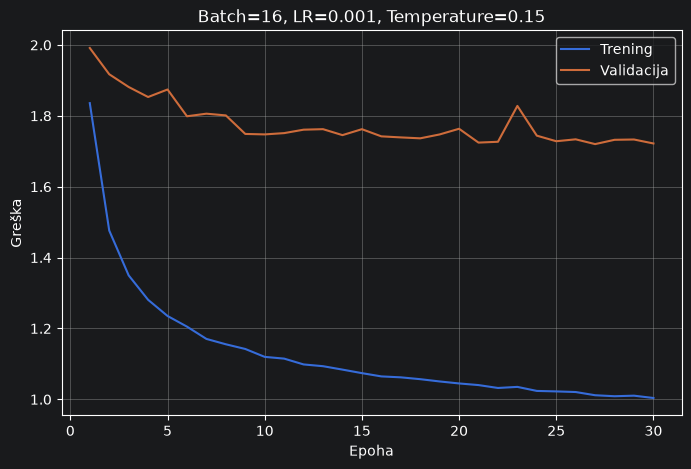

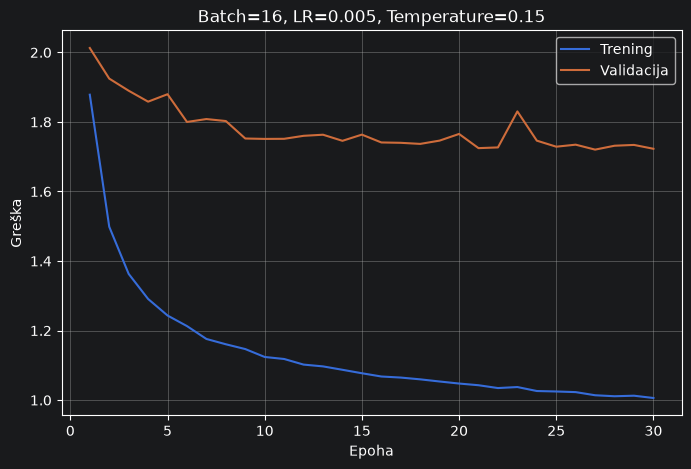

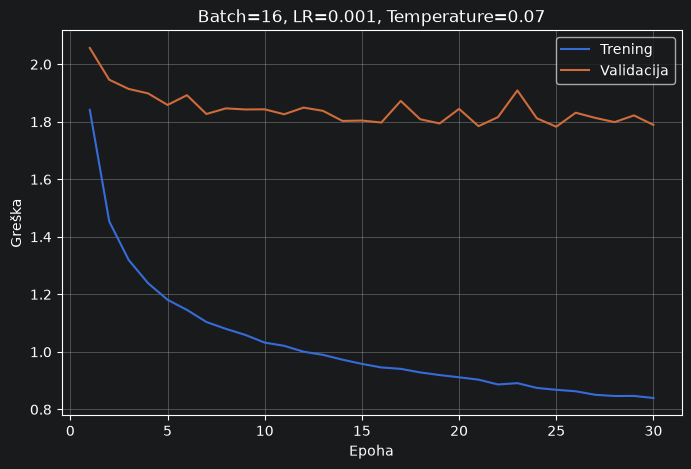

In [20]:
import matplotlib.pyplot as plt

for _, result in final_results.iterrows():
    history = pd.DataFrame(result["history"])

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["epoch"],
        history["train_loss"],
        label="Trening"
    )

    plt.plot(
        history["epoch"],
        history["val_loss"],
        label="Validacija"
    )

    plt.xlabel("Epoha")
    plt.ylabel("Greška")
    plt.title(
        f"Batch={int(result['batch_size'])}, "
        f"LR={result['learning_rate']}, "
        f"Temperature={result['temperature']}"
    )

    plt.legend()
    plt.grid()
    plt.show()

## Zaključak

Na osnovu retrieval rezultata na validation skupu izabrana je konfiguracija koja daje najbolje performanse za zadatak pretrage — ne prosto ona sa najnižim validation loss-om.

Ključne odluke u ovom notebook-u:
- **Grid search i izbor hiperparametara rađeni su isključivo na train/validation skupovima** — `test.pt` nije dotican, čime se izbegava curenje informacija u proces odlučivanja i obezbeđuje nepristrasna konačna evaluacija.
- **Izbor modela zasnovan je na retrieval metrikama (MRR, Recall@10), ne samo na loss vrednosti** — loss je koristan za praćenje treninga, ali ne meri direktno kvalitet pretrage.

Izabrani model će u notebook-u 04 biti evaluiran na `test.pt` skupu (Recall@1, Recall@5, Recall@10, MRR, Mean Rank)
